# 06: Synthetic Control for Gotham FC's Move to Etihad Park

This notebook builds a synthetic "Gotham with no move", built from a donor pool of 
comporable non-relocating NWSL teams, combined with an accessibility-driven effect to project 2027+ attendance/
The move hasn't happened yet (Etihad Park opens 2027), so this can't be a
standard retrospective synthetic control (no real post-treatment period to compare against).
What this notebook builds instead is the **architecture**: a synthetic "Gotham with no move"
counterfactual trajectory, built from a donor pool of comparable non-relocating NWSL teams,
combined with an accessibility-driven effect size to project 2027+ attendance.

**Inputs:** `nwsl-project/data/processed/games_clean.csv`,
`output/relocation_accessibility_vs_attendance.png`'s underlying numbers (recomputed here)
**Outputs:** `output/synthetic_control_weights.csv`, `output/synthetic_control_fit.png`,
`output/gotham_2027_projection.csv`


In [23]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from plot_theme import set_mpl_theme

set_mpl_theme()
OUTPUT_DIR = os.path.join("..", "output")
NWSL_PROJECT_PROCESSED = os.path.join("..", "..", "..", "QSS 20", "nwsl-project", "data", "processed")

# Panel build
games = pd.read_csv(os.path.join(NWSL_PROJECT_PROCESSED, "games_clean.csv"))
teams = pd.read_csv(os.path.join(NWSL_PROJECT_PROCESSED, "teams_clean.csv"))
nwsl_games = games[(games["league"] == "nwsl") & (games["attendance"] > 0)].dropna(subset=["attendance"])
nwsl_games = nwsl_games[~nwsl_games["season_name"].isin([2020, 2021])]
nwsl_games = nwsl_games.merge(teams[["team_id", "team_name"]], left_on="home_team_id", right_on="team_id")

panel = nwsl_games.groupby(["team_name", "season_name"])["attendance"].mean().reset_index()
panel["log_attendance"] = np.log(panel["attendance"])


def fit_scm(panel_df, treated, pre_years, post_years=None, exclude_donors=None):
    """Fits SCM weights on pre_years and evaluates counterfactual."""
    exclude_donors = exclude_donors or []

    # Filter panel to the pre-treatment period
    pre_panel = panel_df[panel_df["season_name"].isin(pre_years)]

    # Identify candidate donor teams with full season coverage across pre_years
    cov = pre_panel.groupby("team_name")["season_name"].nunique()
    full_cov = cov[cov == len(pre_years)].index.tolist()

    # Exclude the treated unit itself and any explicitly excluded teams
    donors = [t for t in full_cov if t not in exclude_donors + [treated]]

    # Construct target vector (treated team) and feature matrix (donor teams)
    treated_pre = pre_panel[
        pre_panel["team_name"] == treated
    ].set_index("season_name")["log_attendance"]
    donor_mat = pre_panel[pre_panel["team_name"].isin(donors)].pivot(
        index="season_name", columns="team_name", values="log_attendance"
    )[donors]

    # Fit SCM weights using constrained least squares optimization
    # Initialize with equal weights
    w0 = np.ones(len(donors)) / len(donors)

    # Minimize squared error subject to: 0 <= w_i <= 1 and sum(w) == 1
    res = minimize(
        lambda w: np.sum((treated_pre.values - donor_mat.values @ w) ** 2),
        w0,
        method="SLSQP",
        bounds=[(0, 1)] * len(donors),
        constraints=[{"type": "eq", "fun": lambda w: np.sum(w) - 1}],
    )
    weights = pd.Series(res.x, index=donors).sort_values(ascending=False)

    # Compute pre-period synthetic trajectory and goodness-of-fit (RMSE)
    synth_pre = pd.Series(
        donor_mat.values @ weights.reindex(donors).values,
        index=donor_mat.index,
    )
    pre_rmse = np.sqrt(np.mean((treated_pre.values - synth_pre.values) ** 2))

    res_dict = {
        "treated": treated,
        "weights": weights,
        "treated_pre": treated_pre,
        "synth_pre": synth_pre,
        "pre_rmse": pre_rmse,
    }

    # If post-treatment years are provided (e.g. for placebo testing), evaluate post-move fit
    if post_years:
        post_panel = panel_df[panel_df["season_name"].isin(post_years)]
        treated_post = post_panel[
            post_panel["team_name"] == treated
        ].set_index("season_name")["log_attendance"]
        donor_post = post_panel[post_panel["team_name"].isin(donors)].pivot(
            index="season_name", columns="team_name", values="log_attendance"
        )[donors]

        # Apply pre-fitted weights to post-period donor outcomes
        synth_post = pd.Series(
            donor_post.values @ weights.reindex(donors).values,
            index=donor_post.index,
        )

        # Calculate actual vs. synthetic mean attendance (converted from log scale) and net lift %
        actual_post_mean = np.exp(treated_post).mean()
        synth_post_mean = np.exp(synth_post).mean()
        scm_lift_pct = (
            (actual_post_mean / synth_post_mean - 1) * 100
        )

        res_dict.update(
            {
                "treated_post": treated_post,
                "synth_post": synth_post,
                "actual_post_mean": actual_post_mean,
                "synth_post_mean": synth_post_mean,
                "scm_lift_pct": scm_lift_pct,
            }
        )

    return res_dict

## Run the SCM attendance panel 
**Pre-period:** 2022-2026, Gotham's current stable state (post their own 2021 Yurcak -> Red
Bull Arena move, which is why the pre-period starts.

**Excluded from the donor pool:**
- Kansas City Current, San Diego Wave, Seattle Reign relocated *during* this same window
  (2024, 2023, 2022). Washington Spirit, however, is included because they relocated in 2021.
- Bay FC, Utah Royals FC, Boston Legacy FC, Denver Summit FC have fewer than 5 seasons of
  post-COVID data, so too little data.


In [24]:
RELOCATORS = ["NJ/NY Gotham FC", "Seattle Reign FC", "Washington Spirit", "San Diego Wave FC", "Kansas City Current"]

# Placebo validations (2016-2019 pre, 2022-2026 post)
placebo_seattle = fit_scm(
    panel, "Seattle Reign FC", range(2016, 2020), range(2022, 2027), [r for r in RELOCATORS if r != "Seattle Reign FC"]
)
placebo_spirit = fit_scm(
    panel,
    "Washington Spirit",
    range(2016, 2020),
    range(2022, 2027),
    [r for r in RELOCATORS if r != "Washington Spirit"],
)

# Gotham pre-move SCM fit (2022-2026 pre)
gotham_scm = fit_scm(
    panel,
    "NJ/NY Gotham FC",
    range(2022, 2027),
    exclude_donors=["San Diego Wave FC", "Seattle Reign FC", "Kansas City Current"],
)

## Calculating the projected attendance numbers

In [25]:
ETIHAD_CAPACITY = 25000

# Synthetic growth rate extrapolated from synthetic 2026
avg_growth = np.diff(gotham_scm["synth_pre"].values).mean()
synth_2026_log = gotham_scm["synth_pre"].iloc[-1]

base_2027 = min(np.exp(synth_2026_log + avg_growth), ETIHAD_CAPACITY)
base_2028 = min(np.exp(synth_2026_log + 2 * avg_growth), ETIHAD_CAPACITY)

lifts = {
    "conservative_seattle_scm": placebo_seattle["scm_lift_pct"] / 100.0,
    "optimistic_spirit_scm": placebo_spirit["scm_lift_pct"] / 100.0,
}

gotham_2026_actual = np.exp(gotham_scm["treated_pre"].iloc[-1])
league_growth = base_2027 - gotham_2026_actual

proj_rows = [
    {
        "scenario": "no_move_baseline",
        "attendance_2027": base_2027,
        "pct_capacity": (base_2027 / ETIHAD_CAPACITY) * 100,
        "league_growth_effect": league_growth,
        "relocation_lift_effect": 0.0,
    }
]

for name, lift in lifts.items():
    total_proj = min(base_2027 * (1.0 + lift), ETIHAD_CAPACITY)
    proj_rows.append(
        {
            "scenario": f"etihad_park_{name}",
            "attendance_2027": total_proj,
            "pct_capacity": (total_proj / ETIHAD_CAPACITY) * 100,
            "league_growth_effect": league_growth,
            "relocation_lift_effect": total_proj - base_2027,
        }
    )

proj_df = pd.DataFrame(proj_rows)
proj_df.to_csv(os.path.join(OUTPUT_DIR, "gotham_2027_projection.csv"), index=False)
display(proj_df.round(1))

,scenario,attendance_2027,pct_capacity,league_growth_effect,relocation_lift_effect
0,no_move_baseline,11594.6,46.4,694.3,0.0
1,etihad_park_conservative_seattle_scm,16970.6,67.9,694.3,5376.0
2,etihad_park_optimistic_spirit_scm,24248.1,97.0,694.3,12653.5


## Visualize 2027-2028 Projections

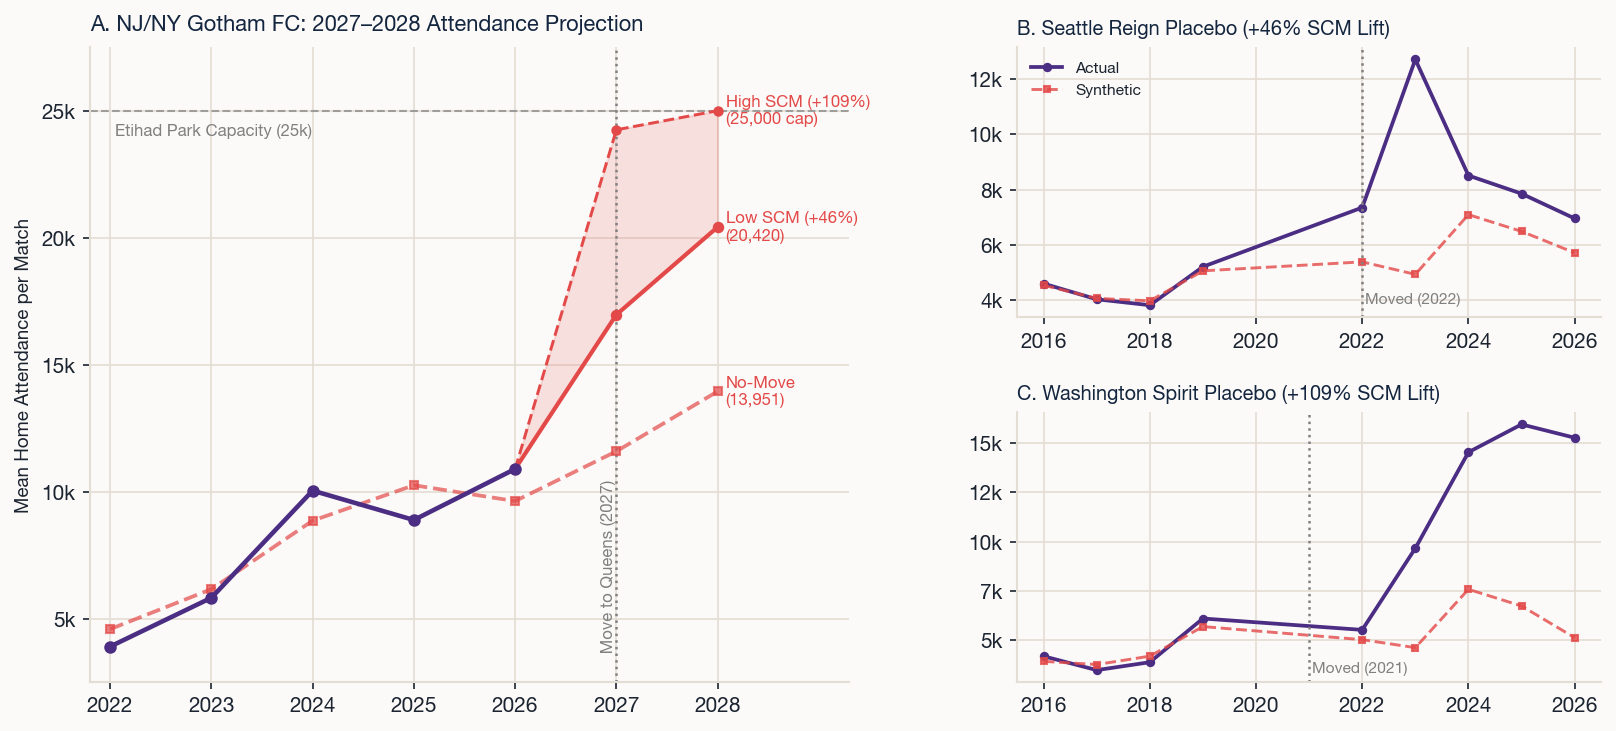

In [35]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np
from plot_theme import set_mpl_theme

# Apply project theme
set_mpl_theme()

fig = plt.figure(figsize=(13, 5.5), dpi=150)
gs = gridspec.GridSpec(2, 2, width_ratios=[1.3, 1.0], wspace=0.25, hspace=0.35)

# Semantic 2-Color Palette
C_ACTUAL = "#4B2E83"  # Primary purple: observed real data
C_SYNTH = "#E34948"   # Coral/red: synthetic counterfactuals & projections
C_REF = "gray"        # Neutral reference

# -------------------------------------------------------------
# Panel A: Main Gotham Forecast (Left, spans both rows)
# -------------------------------------------------------------
ax_main = fig.add_subplot(gs[:, 0])

# Capacity reference
ax_main.axhline(
    ETIHAD_CAPACITY, color=C_REF, linestyle="--", linewidth=1, alpha=0.7
)
ax_main.text(
    2022.05,
    ETIHAD_CAPACITY - 500,
    "Etihad Park Capacity (25k)",
    color=C_REF,
    fontsize=8,
    va="top",
)

# Historical and counterfactual trajectories
gotham_2026_val = np.exp(gotham_scm["treated_pre"].iloc[-1])
ax_main.plot(
    years_actual,
    np.exp(gotham_scm["treated_pre"].values),
    "o-",
    color=C_ACTUAL,
    linewidth=2.2,
    markersize=5,
    zorder=5,
    label="Actual Gotham",
)
ax_main.plot(
    all_yrs,
    synth_full,
    "s--",
    color=C_SYNTH,
    linewidth=1.8,
    markersize=4,
    alpha=0.7,
    zorder=3,
    label="No-Move Baseline",
)

# Continuous fan lines (2026 -> 2027 -> 2028)
fan_yrs = [2026, 2027, 2028]
curve_low = [gotham_2026_val, t_2027_low, t_2028_low]
curve_high = [gotham_2026_val, t_2027_high, t_2028_high]
curve_base = [gotham_2026_val, base_2027, base_2028]

# Shading only the range of uncertainty between the two post-move scenarios
ax_main.fill_between(
    fan_yrs,
    curve_low,
    curve_high,
    color=C_SYNTH,
    alpha=0.15,
    zorder=2,
    label="Relocation Lift Range (+46% to +109%)"
)
ax_main.plot(
    fan_yrs,
    curve_low,
    "o-",
    color=C_SYNTH,
    linewidth=2,
    markersize=4.5,
    zorder=4
)
ax_main.plot(
    fan_yrs,
    curve_high,
    "o--",
    color=C_SYNTH,
    linewidth=1.4,
    markersize=4,
    zorder=4
)

# 2027 Move line
ax_main.axvline(2027, color=C_REF, linestyle=":", linewidth=1.2)
ax_main.text(
    2027,
    3500,
    " Move to Queens (2027)",
    color=C_REF,
    fontsize=8,
    va="bottom",
    ha="right",
    rotation=90,
)

# Endpoint labels
ax_main.text(
    2028.08,
    synth_full[-1],
    f"No-Move\n({synth_full[-1]:,.0f})",
    color=C_SYNTH,
    fontsize=8,
    va="center",
)
ax_main.text(
    2028.08,
    t_2028_low,
    f"Low SCM (+46%)\n({t_2028_low:,.0f})",
    color=C_SYNTH,
    fontsize=8,
    va="center",
)
ax_main.text(
    2028.08,
    t_2028_high,
    f"High SCM (+109%)\n({t_2028_high:,.0f} cap)",
    color=C_SYNTH,
    fontsize=8,
    va="center",
)

ax_main.set_xlim(2021.8, 2029.3)
ax_main.set_ylim(2500, 27500)
ax_main.set_xticks(all_yrs)
ax_main.set_title(
    "A. NJ/NY Gotham FC: 2027–2028 Attendance Projection",
    fontsize=10.5,
    fontweight="bold",
    loc="left",
    pad=8,
)
ax_main.set_ylabel("Mean Home Attendance per Match", fontsize=9)

# -------------------------------------------------------------
# Panels B & C: Placebos (Top & Bottom Right)
# -------------------------------------------------------------
placebo_configs = [
    (
        placebo_seattle,
        2022,
        f"B. Seattle Reign Placebo (+{placebo_seattle['scm_lift_pct']:.0f}% SCM Lift)",
        gs[0, 1],
    ),
    (
        placebo_spirit,
        2021,
        f"C. Washington Spirit Placebo (+{placebo_spirit['scm_lift_pct']:.0f}% SCM Lift)",
        gs[1, 1],
    ),
]

for p_data, move_yr, title, subplot_spec in placebo_configs:
    ax = fig.add_subplot(subplot_spec)
    p_yrs = list(p_data["treated_pre"].index) + list(
        p_data["treated_post"].index
    )

    ax.plot(
        p_yrs,
        list(np.exp(p_data["treated_pre"]))
        + list(np.exp(p_data["treated_post"])),
        "o-",
        color=C_ACTUAL,
        linewidth=1.8,
        markersize=3.5,
        label="Actual",
    )
    ax.plot(
        p_yrs,
        list(np.exp(p_data["synth_pre"])) + list(np.exp(p_data["synth_post"])),
        "s--",
        color=C_SYNTH,
        linewidth=1.4,
        markersize=3,
        alpha=0.8,
        label="Synthetic",
    )

    ax.axvline(move_yr, color=C_REF, linestyle=":", linewidth=1.2)
    ax.text(
        move_yr + 0.05,
        ax.get_ylim()[0] + 500,
        f"Moved ({move_yr})",
        color=C_REF,
        fontsize=7.5,
    )
    ax.set_title(title, fontsize=9.5, fontweight="bold", loc="left", pad=6)

# Single minimal legend on top-right subplot
fig.axes[1].legend(loc="upper left", fontsize=7.5, frameon=False)

# Format y-axes across all subplots
for ax in fig.axes:
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, p: f"{int(x/1000)}k" if x > 0 else "0")
    )

plt.savefig(
    os.path.join(OUTPUT_DIR, "synthetic_control_hierarchical_summary.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()